In [ ]:
import os

# Navigate to project root
os.chdir('..')
print("Current folder:", os.getcwd())

Current folder: c:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map


In [ ]:
# Run this once to install the library
import subprocess
subprocess.run(['pip', 'install', 'osmnx'])

CompletedProcess(args=['pip', 'install', 'osmnx'], returncode=0)

In [3]:
import osmnx as ox
import geopandas as gpd

print("Downloading Delhi road network...")

# Download all roads in Delhi
delhi_roads = ox.graph_from_place(
    'Delhi, India',
    network_type='drive'    # only driveable roads
)

# Convert to a GeoDataFrame (table format)
edges = ox.graph_to_gdfs(delhi_roads, nodes=False)

# Save to file
edges.to_file('data/raw/delhi_roads.gpkg', driver='GPKG')

print(f"✅ Roads downloaded!")
print(f"Total road segments: {len(edges)}")
print(edges.head())

✅ Roads downloaded!
Total road segments: 24399
                                                     osmid      highway  \
u        v          key                                                   
58056528 301037382  0                            590609974      primary   
         7612915570 0               [558065085, 558065079]    secondary   
60890393 6436786516 0                           1121966690  residential   
         6110396131 0                             25744598     tertiary   
         280740684  0    [583917363, 1312224221, 44317159]      primary   

                                        name  oneway reversed      length  \
u        v          key                                                     
58056528 301037382  0    Nelson Mandela Marg    True    False   31.509355   
         7612915570 0             Palam Marg    True    False  325.637170   
60890393 6436786516 0                    NaN   False     True   17.640539   
         6110396131 0                    N

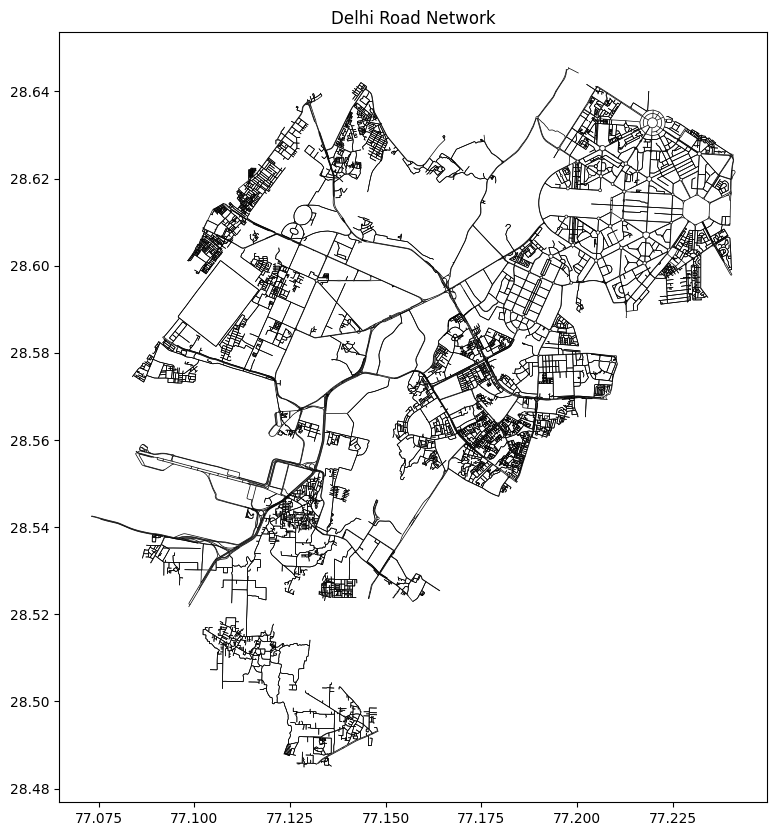

✅ Road map saved to outputs/


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=0.5, color='black')
ax.set_title('Delhi Road Network')
plt.savefig('outputs/delhi_roads_map.png', dpi=300)
plt.show()

print("✅ Road map saved to outputs/")

In [6]:
import ee
import os

ee.Initialize(project='teak-catwalk-473711-r3')

# Define Delhi boundary
delhi = ee.Geometry.Rectangle([76.8, 28.4, 77.4, 28.9])

# Load SRTM elevation data
elevation = ee.Image('USGS/SRTMGL1_003') \
    .clip(delhi)

# Export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=elevation,
    description='Delhi_Elevation',
    folder='airquality_data',
    fileNamePrefix='delhi_elevation',
    region=delhi,
    scale=30,           # 30 meter resolution
    crs='EPSG:4326',
    fileFormat='GeoTIFF'
)
task.start()
print("✅ Elevation export started!")
print(f"Task status: {task.status()}")

c:\Users\USER\anaconda3\envs\airquality\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Elevation export started!
Task status: {'state': 'READY', 'description': 'Delhi_Elevation', 'priority': 100, 'creation_timestamp_ms': 1774705365578, 'update_timestamp_ms': 1774705365578, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'HSO2ZHZHHQFTT7HPBCPTHG3R', 'name': 'projects/teak-catwalk-473711-r3/operations/HSO2ZHZHHQFTT7HPBCPTHG3R'}


In [12]:
# Load MODIS land cover data
landuse = ee.ImageCollection('MODIS/061/MCD12Q1') \
    .filterDate('2023-01-01', '2023-12-31') \
    .first() \
    .select('LC_Type1') \
    .clip(delhi)

# Export to Google Drive
task2 = ee.batch.Export.image.toDrive(
    image=landuse,
    description='Delhi_LandUse',
    folder='airquality_data',
    fileNamePrefix='delhi_landuse',
    region=delhi,
    scale=500,          # 500 meter resolution
    crs='EPSG:4326',
    fileFormat='GeoTIFF'
)
task2.start()
print("✅ Land use export started!")
print(f"Task status: {task2.status()}")

✅ Land use export started!
Task status: {'state': 'READY', 'description': 'Delhi_LandUse', 'priority': 100, 'creation_timestamp_ms': 1774705948719, 'update_timestamp_ms': 1774705948719, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'KPXGXL7HLTXO67EFPMDP65VP', 'name': 'projects/teak-catwalk-473711-r3/operations/KPXGXL7HLTXO67EFPMDP65VP'}


In [8]:
# Load WorldPop population density
population = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filterDate('2020-01-01', '2020-12-31') \
    .filter(ee.Filter.eq('country', 'IND')) \
    .first() \
    .clip(delhi)

# Export to Google Drive
task3 = ee.batch.Export.image.toDrive(
    image=population,
    description='Delhi_Population',
    folder='airquality_data',
    fileNamePrefix='delhi_population',
    region=delhi,
    scale=100,          # 100 meter resolution
    crs='EPSG:4326',
    fileFormat='GeoTIFF'
)
task3.start()
print("✅ Population export started!")
print(f"Task status: {task3.status()}")

✅ Population export started!
Task status: {'state': 'READY', 'description': 'Delhi_Population', 'priority': 100, 'creation_timestamp_ms': 1774705437288, 'update_timestamp_ms': 1774705437288, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'CHO3WB7LRMYCMJGPER7YFL5R', 'name': 'projects/teak-catwalk-473711-r3/operations/CHO3WB7LRMYCMJGPER7YFL5R'}


In [13]:
# Check status of all exports
print("Elevation task:", task.status()['state'])
print("Land use task:", task2.status()['state'])
print("Population task:", task3.status()['state'])

Elevation task: COMPLETED
Land use task: COMPLETED
Population task: COMPLETED
